# One-Factor ANOVA

**One-Factor ANOVA** tests whether the means of k ≥ 2 groups are equal. It partitions total variance into between-group (treatment) and within-group (error) components.

| Property | Value |
|---|---|
| **H₀** | μ₁ = μ₂ = ⋯ = μₖ |
| **H₁** | At least one μᵢ differs |
| **Test statistic** | F = MSₜᵣₑₐₜ / MSₑᵣᵣ |
| **Distribution** | F(k−1, N−k) under H₀ |
| **SS partition** | SStotal = SSbetween + SSwithin |
| **Assumptions** | Normality, equal variances, independence |
| **Post-hoc** | Tukey HSD, Bonferroni if F is significant |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    HAS_SM = True
except ImportError:
    HAS_SM = False

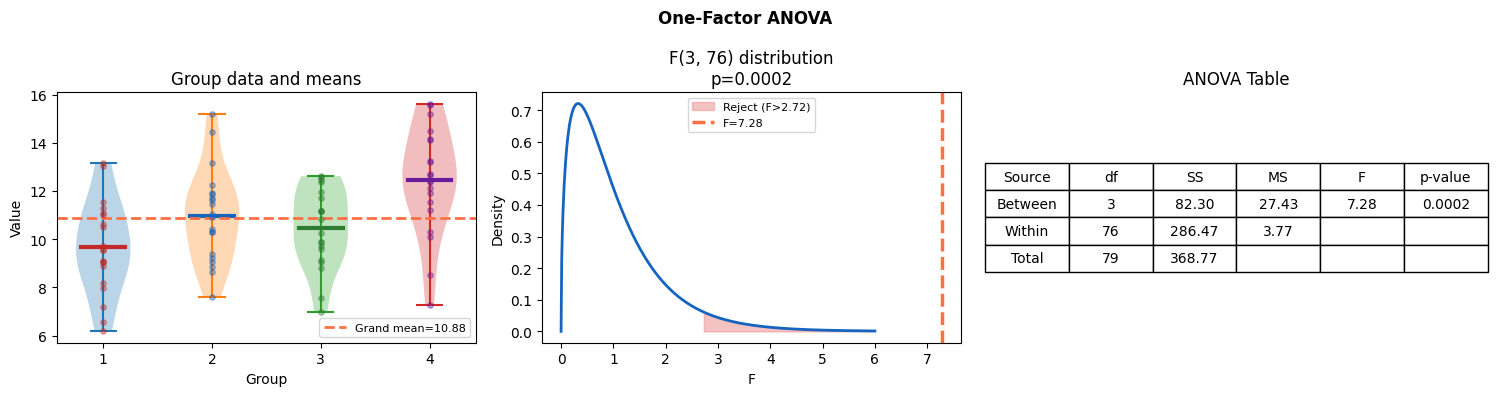

scipy F=7.2784, p=0.0002
Manual F=7.2784, p=0.0002
η² (effect size) = SS_between/SS_total = 0.223


In [2]:
np.random.seed(42)
k = 4
n_per = 20
group_means = [10.0, 11.5, 10.5, 12.5]
sigma = 2.0

groups = [np.random.normal(mu, sigma, n_per) for mu in group_means]
N = k * n_per

# ANOVA by hand
grand_mean = np.concatenate(groups).mean()
ss_between = sum(n_per * (g.mean() - grand_mean)**2 for g in groups)
ss_within  = sum(((g - g.mean())**2).sum() for g in groups)
ms_between = ss_between / (k - 1)
ms_within  = ss_within  / (N - k)
F_stat = ms_between / ms_within
p_val = stats.f.sf(F_stat, k-1, N-k)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('One-Factor ANOVA', fontsize=12, fontweight='bold')

# Panel 1: group distributions
colors = ['#C62828', '#1565C0', '#2E7D32', '#6A1B9A']
for i, (g, color) in enumerate(zip(groups, colors)):
    axes[0].violinplot(g, positions=[i+1], showmeans=True, showmedians=False)
    axes[0].scatter([i+1]*len(g), g, color=color, alpha=0.4, s=15, zorder=3)
    axes[0].plot([i+0.8, i+1.2], [g.mean(), g.mean()], color=color, lw=3)
axes[0].axhline(grand_mean, color='#FF7043', lw=2, ls='--', label=f'Grand mean={grand_mean:.2f}')
axes[0].set_title('Group data and means'); axes[0].set_xlabel('Group')
axes[0].set_ylabel('Value'); axes[0].set_xticks(range(1, k+1))
axes[0].legend(fontsize=8)

# Panel 2: F-distribution
f_range = np.linspace(0, 6, 500)
f_pdf = stats.f.pdf(f_range, k-1, N-k)
f_crit = stats.f.ppf(0.95, k-1, N-k)
axes[1].plot(f_range, f_pdf, color='#1565C0', lw=2)
axes[1].fill_between(f_range, f_pdf, where=f_range >= f_crit, color='#EF9A9A', alpha=0.6, label=f'Reject (F>{f_crit:.2f})')
axes[1].axvline(F_stat, color='#FF7043', lw=2.5, ls='--', label=f'F={F_stat:.2f}')
axes[1].set_title(f'F({k-1}, {N-k}) distribution\np={p_val:.4f}')
axes[1].set_xlabel('F'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

# Panel 3: ANOVA table
table_data = [
    ['Between', f'{k-1}', f'{ss_between:.2f}', f'{ms_between:.2f}', f'{F_stat:.2f}', f'{p_val:.4f}'],
    ['Within',  f'{N-k}', f'{ss_within:.2f}',  f'{ms_within:.2f}',  '',              ''],
    ['Total',   f'{N-1}', f'{ss_between+ss_within:.2f}', '', '', ''],
]
axes[2].axis('off')
cols = ['Source', 'df', 'SS', 'MS', 'F', 'p-value']
tbl = axes[2].table(cellText=table_data, colLabels=cols,
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
tbl.scale(1.2, 2.0)
axes[2].set_title('ANOVA Table')

plt.tight_layout(); plt.show()

F2, p2 = stats.f_oneway(*groups)
print(f'scipy F={F2:.4f}, p={p2:.4f}')
print(f'Manual F={F_stat:.4f}, p={p_val:.4f}')
print(f'η² (effect size) = SS_between/SS_total = {ss_between/(ss_between+ss_within):.3f}')

## Key Takeaways

| | |
|---|---|
| **F = MSbetween/MSwithin** | Large F → between-group variation dominates noise |
| **η² (eta-squared)** | SS_between/SS_total — proportion of variance explained by group |
| **Significant F** | Only means at least one pair differs — need post-hoc tests for which |
| **Tukey HSD** | Controls family-wise error rate for all pairwise comparisons |
| **Equal variances** | ANOVA assumes σ₁=⋯=σₖ; check with Levene or Bartlett test |
| **Normality** | Check per group with Q-Q plot; ANOVA is robust for n ≥ 20 per group |